### BIG DATA LAB3: Machine Learning on Spark
**Thực hiện tính ma trận tương quan giữa các thuộc tính để chọn thuộc tính phù hợp**

*Thực hiện cây quyết định dự đoán trên tập dữ liệu NYC Taxi Trip Duration với RDD (low-level)*

Họ và tên: Phan Bá Đức

MSSV: 22120071

In [1]:
from pyspark.sql import SparkSession
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
spark = SparkSession.builder \
    .appName("CorrelationMatrixRDDNYCTaxi") \
    .master("local[*]") \
    .getOrCreate()

25/05/09 22:42:36 WARN Utils: Your hostname, Luminous resolves to a loopback address: 127.0.1.1; using 192.168.1.17 instead (on interface wlp0s20f3)
25/05/09 22:42:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/09 22:42:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/05/09 22:42:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
sc = spark.sparkContext
print(f"Spark master: {sc.master}")
print("Spark UI URL:", spark.sparkContext.uiWebUrl)

Spark master: local[*]
Spark UI URL: http://192.168.1.17:4041


In [4]:
train_lines = sc.textFile("hdfs://localhost:9000/hcmus/nyc-taxi-trip-duration/train.csv")

In [5]:
# Parse dữ liệu
header_train = train_lines.first()
train_data = train_lines.filter(lambda line: line != header_train)

In [6]:
train_data.take(5)

['id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982154846191406,40.767936706542969,-73.964630126953125,40.765602111816406,N,455',
 'id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415344238281,40.738563537597656,-73.999481201171875,40.731151580810547,N,663',
 'id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979026794433594,40.763938903808594,-74.005332946777344,40.710086822509766,N,2124',
 'id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040283203125,40.719970703125,-74.01226806640625,40.706718444824219,N,429',
 'id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973052978515625,40.793209075927734,-73.972923278808594,40.782520294189453,N,435']

In [7]:
header_train

'id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration'

In [8]:
numeric_indices = [4, 5, 6, 7, 8, 10]
numeric_cols = [header_train.split(",")[i] for i in numeric_indices]

def parse_numeric(line):
    try:
        fields = line.split(",")
        # Convert the numeric fields to float
        numeric_values = [float(fields[i]) for i in numeric_indices]
        if any(v is None for v in numeric_values):
            return None
        return numeric_values
    except ValueError:
        # Handle the case where conversion fails
        return None

In [9]:
rdd_numeric = train_data.map(parse_numeric).filter(lambda x: x is not None).cache()
rdd_numeric = rdd_numeric.repartition(64)

print("Number of partitions:", rdd_numeric.getNumPartitions())
print("Number of records:", rdd_numeric.count())
print("Sample numeric data:")
sample = rdd_numeric.take(5)
for i, row in enumerate(sample):
    print(f"Row {i}: {row}")


Number of partitions: 64


Number of records: 1458644
Sample numeric data:
Row 0: [2.0, -73.96112060546875, 40.771968841552734, -73.96575927734375, 40.76543045043945, 445.0]
Row 1: [1.0, -73.97798156738281, 40.68478012084961, -73.95413208007812, 40.613346099853516, 1537.0]
Row 2: [1.0, -73.95896911621094, 40.768009185791016, -73.98249053955078, 40.76605987548828, 843.0]
Row 3: [6.0, -73.98092651367188, 40.77969741821289, -73.97502136230469, 40.784332275390625, 174.0]
Row 4: [2.0, -73.9705810546875, 40.758731842041016, -73.99867248535156, 40.74982833862305, 942.0]


---
### Tính ma trận tương quan

##### Hiệp phương sai (Covariance)
Hiệp phương sai giữa hai biến $ X $ và $ Y $ đo lường mức độ hai biến thay đổi cùng nhau:

$$
\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

Trong đó:
- $ y_i $: Giá trị của biến $ Y $ tại mẫu $ i $.
- $ \bar{y} $: Giá trị trung bình của $ Y $.
- Nếu $ \text{Cov}(X, Y) > 0 $: $ X $ và $ Y $ có xu hướng tăng/giảm cùng nhau.
- Nếu $ \text{Cov}(X, Y) < 0 $: $ X $ tăng thì $ Y $ giảm và ngược lại.
- Nếu $ \text{Cov}(X, Y) \approx 0 $: Không có mối quan hệ tuyến tính rõ ràng.

##### Hệ số tương quan Pearson
Hệ số tương quan Pearson giữa $ X $ và $ Y $ được chuẩn hóa từ hiệp phương sai:

$$
\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

Trong đó:
- $ \sigma_X, \sigma_Y $: Độ lệch chuẩn của $ X $ và $ Y $.
- $ \rho_{X,Y} \in [-1, 1] $:
  - $ \rho_{X,Y} = 1 $: Tương quan tuyến tính hoàn hảo (cùng hướng).
  - $ \rho_{X,Y} = -1 $: Tương quan tuyến tính hoàn hảo (ngược hướng).
  - $ \rho_{X,Y} = 0 $: Không có tương quan tuyến tính.

##### **Tính ma trận tương quan**:
   - Tạo ma trận $ k \times k $, trong đó phần tử tại $ (j, k) $ là:
     $$
     \rho_{j,k} = \frac{\text{Cov}(X_j, X_k)}{\sigma_j \sigma_k}
     $$
   - Đối với $ j = k $, $ \rho_{j,j} = 1 $ (tương quan với chính nó).
   - Ma trận đối xứng: $ \rho_{j,k} = \rho_{k,j} $.

In [10]:
# Tính trung bình cho từng cột
'''Ví dụ
    [1.0, 2.0, 3.0] 
    [4.0, 5.0, 6.0] 
    [7.0, 8.0, 9.0]
Thao tác trên lần lượt từng dòng
    [5.0, 7.0, 9.0]
    [7.0, 8.0, 9.0]
Tiếp theo
    [12.0, 15.0, 18.0]
'''
n = rdd_numeric.count()
sums = rdd_numeric.reduce(lambda a, b: [x + y for x, y in zip(a, b)])
means = [s / n for s in sums]

In [ ]:
# Tính phương sai và hiệp phương sai
'''Ví dụ
row = [1.0, 2.0, 3.0]
means = [4.0, 5.0, 6.0]
=> row - means = [-3.0, -3.0, -3.0]
'''
def compute_diff(row, means):
    return [(x - m) for x, m in zip(row, means)]

rdd_diff = rdd_numeric.map(lambda row: compute_diff(row, means))

# Tính tích (xi - mean_x)(yi - mean_y) cho hiệp phương sai
'''Ví dụ
row = [1.0, 2.0, 3.0]
=> [(0, 0, 1.0), (0, 1, 2.0), (0, 2, 3.0), (1, 1, 4.0), (1, 2, 6.0), (2, 2, 9.0)]
'''
def compute_products(row):
    products = []
    for i in range(len(row)):
        for j in range(i, len(row)):
            products.append((i, j, row[i] * row[j]))
    return products

rdd_products = rdd_diff.flatMap(compute_products)
sum_products = rdd_products.map(lambda x: ((x[0], x[1]), x[2])).reduceByKey(lambda a, b: a + b)
# Vì dữ liệu đã được chuyển về (key, value) với dạng ((i, j), value) nên x[0] là (i, j) vì vậy x[0][0] = i, x[0][1] = j; và x[1] là value
cov_matrix = sum_products.map(lambda x: (x[0][0], x[0][1], x[1] / n)).collect()


In [12]:
# Tạo ma trận hiệp phương sai
cov_dict = {(i, j): cov for i, j, cov in cov_matrix}
corr_matrix = [[0.0] * len(numeric_cols) for _ in range(len(numeric_cols))]
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if i <= j:
            corr_matrix[i][j] = cov_dict.get((i, j), cov_dict.get((j, i), 0.0))
        else:
            corr_matrix[i][j] = corr_matrix[j][i]

# Tính độ lệch chuẩn (sqrt(Var))
    # Phương sai là hiệp phương sai với chính nó
variances = [cov_dict.get((i, i), 0.0) for i in range(len(numeric_cols))]
std_devs = [np.sqrt(var) for var in variances]

# Tính ma trận tương quan
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if std_devs[i] * std_devs[j] != 0:
            corr_matrix[i][j] /= (std_devs[i] * std_devs[j])
        else:
            corr_matrix[i][j] = 0.0

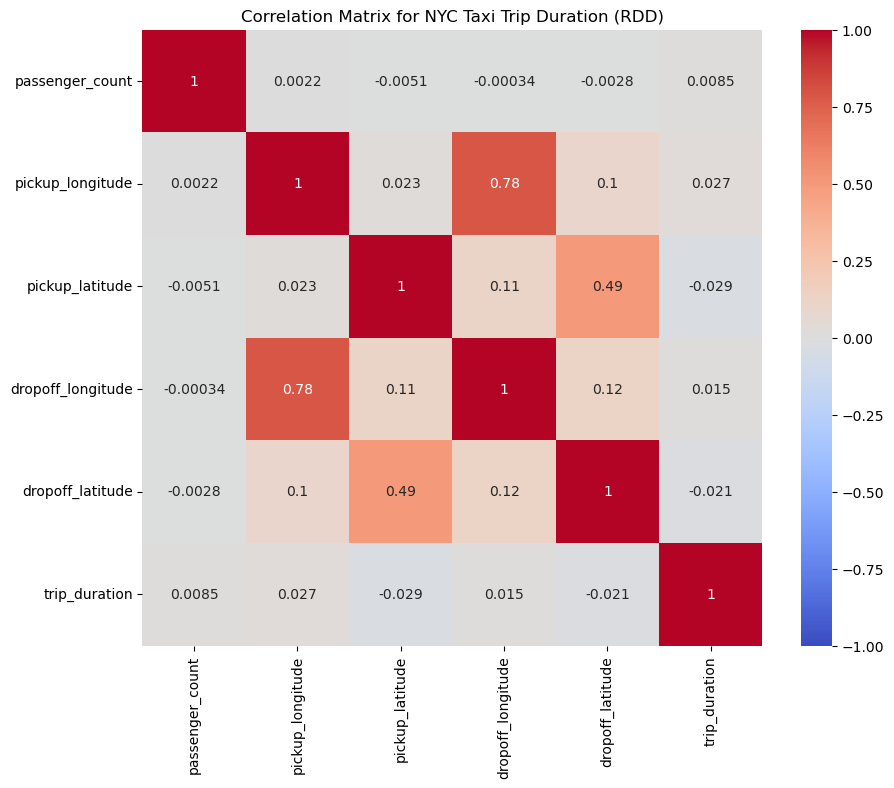


Phân tích đặc trưng:
Tương quan với trip_duration:
passenger_count      0.008471
pickup_longitude     0.026542
pickup_latitude     -0.029204
dropoff_longitude    0.014678
dropoff_latitude    -0.020677
Name: trip_duration, dtype: float64

Đặc trưng được đề xuất (tương quan tuyệt đối > 0.01): ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']


In [13]:
# Chuyển sang pandas DataFrame
corr_df = pd.DataFrame(corr_matrix, columns=numeric_cols, index=numeric_cols)

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation Matrix for NYC Taxi Trip Duration (RDD)")
plt.show()

# Phân tích để chọn đặc trưng
print("\nPhân tích đặc trưng:")
trip_duration_corr = corr_df["trip_duration"].drop("trip_duration")
print("Tương quan với trip_duration:")
print(trip_duration_corr)

# Đề xuất đặc trưng
selected_features = trip_duration_corr[abs(trip_duration_corr) > 0.01].index.tolist()
print(f"\nĐặc trưng được đề xuất (tương quan tuyệt đối > 0.01): {selected_features}")

In [14]:
spark.stop()